# Geracao de DAG por GES (score-based)

Este notebook roda o algoritmo GES (Greedy Equivalence Search) para inferir um CPDAG a partir dos dados.
Ele foi inspirado nas aulas (menciona PC, GES, NOTEARS) e complementa o PC ja usado no projeto.

Objetivo: gerar uma estrutura alternativa para comparar com o DAG teorico.

## O que este notebook faz

- Roda GES (score-based) para gerar um CPDAG.
- Usa as mesmas variaveis do pipeline do Lucas para comparacao.
- Serve como diagnostico exploratorio; o DAG teorico continua referencia.

In [17]:
%pip install causal-learn networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Dependencias

Execute esta celula uma vez por ambiente.
Se ja instalou, pode pular.

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from causallearn.search.ScoreBased.GES import ges

In [19]:
DATA_PATH = Path('data/processed/sim_selected/dataset.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Arquivo nao encontrado: {DATA_PATH}. Atualize o caminho acima.')

df = pd.read_csv(DATA_PATH)
df.head()

,ano,sigla_uf,sequencial_obito,causa_basica,data_obito,hora_obito,naturalidade,data_nascimento,idade,escolaridade,...,id_municipio_ocorrencia,ocupacao,local_ocorrencia,assistencia_medica,necropsia,codigo_estabelecimento,atestante,morte_evitavel,escolaridade_grupo,escolaridade_nivel
0,2012,AC,2697.0,V449,2012-05-04,19:00:00,NaN,1982-03-20,30.0,3.0,...,1100205,999992.0,4,2.0,1.0,NaN,3.0,1,media,1
1,2012,AC,1172.0,Y099,2012-01-07,NaN,NaN,1955-07-02,56.0,2.0,...,1100205,715505.0,5,2.0,1.0,NaN,3.0,1,media,1
2,2012,AC,1298.0,C61,2012-03-03,13:55:00,NaN,1950-06-10,61.0,2.0,...,1200013,612005.0,2,1.0,2.0,5701929.0,1.0,0,media,1
3,2012,AC,1297.0,I64,2012-02-26,04:05:00,NaN,1940-09-28,71.0,2.0,...,1200013,999993.0,1,9.0,NaN,5701929.0,5.0,1,media,1
4,2012,AC,1306.0,C959,2012-05-24,10:30:00,NaN,1942-02-11,70.0,3.0,...,1200013,517205.0,2,1.0,2.0,5701929.0,1.0,0,media,1


## Carregamento dos dados

Usa `data/processed/sim_selected/dataset.csv`.
Se o arquivo nao existir, gere o dataset primeiro.

In [ ]:
# Selecione as colunas usadas no DAG. Ajuste conforme necessario.
# Criamos uma versao discretizada de idade para uso no GES.
# Usamos escolaridade_grupo no lugar de escolaridade_nivel e mantemos sigla_uf.
# local_ocorrencia nao e redundante com UF, mas fica fora do nucleo do DAG por representar o contexto imediato do obito.
if 'idade' in df.columns:
    df['idade_grupo'] = pd.cut(
        df['idade'],
        bins=[0, 25, 45, 60, 75, 120],
        labels=['0-24', '25-44', '45-59', '60-74', '75+']
    )

cols_of_interest = [
    'idade_grupo',
    'sexo',
    'raca_cor',
    'escolaridade_grupo',
    'sigla_uf',
    'morte_evitavel',
    'ocupacao',
    'ano'
 ]

df_model = df[cols_of_interest].dropna().copy()
# Opcional: reduzir amostra para acelerar o GES
# df_model = df_model.sample(n=50000, random_state=42)

## Preparacao das variaveis

- Discretiza idade para `idade_grupo` (necessario para score discreto).
- Seleciona as variaveis do DAG com escolaridade_grupo, sigla_uf e ano; local_ocorrencia fica fora do nucleo analitico.
- Remove linhas com NA (casos completos).

Arestas dirigidas: 11
Arestas nao dirigidas: 3


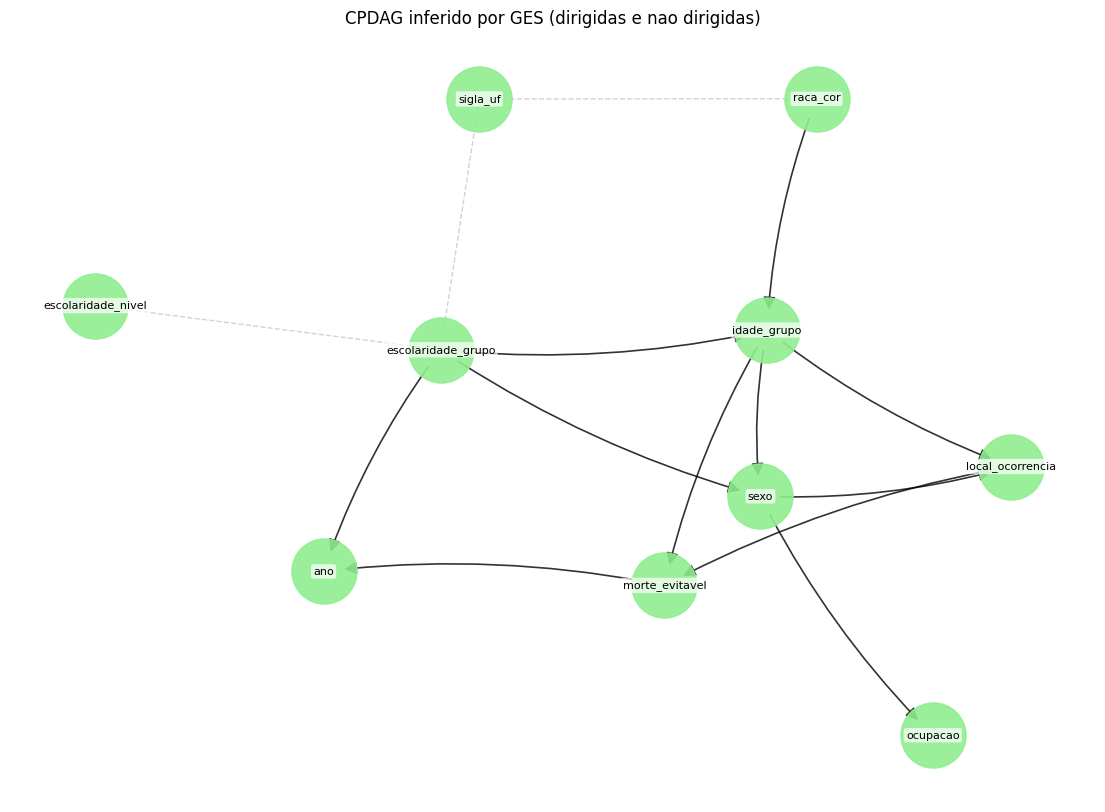

In [21]:
def encode_discrete(df_in):
    df_out = df_in.copy()
    encoders = {}
    for col in df_out.columns:
        le = LabelEncoder()
        df_out[col] = le.fit_transform(df_out[col].astype(str))
        encoders[col] = le
    return df_out, encoders

# Amostragem para reduzir custo computacional
sample_size = 50000
if len(df_model) > sample_size:
    df_sample = df_model.sample(n=sample_size, random_state=42)
else:
    df_sample = df_model
df_enc, encoders = encode_discrete(df_sample)
X = df_enc.to_numpy()
node_names = list(df_enc.columns)

# GES com score discreto (BDeu). Para dados continuos, troque para local_score_BIC.
record = ges(X=X, score_func='local_score_BDeu', maxP=4, node_names=node_names)
G = record['G']

def extract_edges_from_adjacency(G):
    adj = G.graph
    names = G.get_node_names()
    n = len(names)
    directed = []
    undirected = []
    for i in range(n):
        for j in range(i + 1, n):
            if adj[j, i] == 1 and adj[i, j] == -1:
                directed.append((names[i], names[j]))
            elif adj[i, j] == 1 and adj[j, i] == -1:
                directed.append((names[j], names[i]))
            elif adj[i, j] == -1 and adj[j, i] == -1:
                undirected.append((names[i], names[j]))
    return directed, undirected

directed_edges, undirected_edges = extract_edges_from_adjacency(G)
print('Arestas dirigidas:', len(directed_edges))
print('Arestas nao dirigidas:', len(undirected_edges))

# Plot do CPDAG (setas + arestas nao orientadas)
show_undirected = True
layout = 'kamada_kawai'  # 'kamada_kawai', 'spring' ou 'circular'

G_dir = nx.DiGraph()
G_und = nx.Graph()
G_dir.add_nodes_from(node_names)
G_und.add_nodes_from(node_names)
G_dir.add_edges_from(directed_edges)
G_und.add_edges_from(undirected_edges)

base_graph = nx.Graph()
base_graph.add_nodes_from(node_names)
base_graph.add_edges_from(directed_edges)
if show_undirected:
    base_graph.add_edges_from(undirected_edges)

if layout == 'kamada_kawai':
    pos = nx.kamada_kawai_layout(base_graph)
elif layout == 'circular':
    pos = nx.circular_layout(base_graph)
else:
    k = 1.5 / np.sqrt(len(node_names))
    pos = nx.spring_layout(base_graph, seed=42, k=k, iterations=200)

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G_dir, pos, node_size=2200, node_color='lightgreen', alpha=0.9)
nx.draw_networkx_labels(
    G_dir,
    pos,
    font_size=8,
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7)
 )
nx.draw_networkx_edges(
    G_dir,
    pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=18,
    width=1.2,
    alpha=0.8,
    min_source_margin=15,
    min_target_margin=15,
    connectionstyle='arc3,rad=0.08'
 )
if show_undirected:
    nx.draw_networkx_edges(G_und, pos, style='dashed', edge_color='gray', width=1.0, alpha=0.35)

plt.title('CPDAG inferido por GES (dirigidas e nao dirigidas)')
plt.axis('off')
plt.show()

## Resultado do GES

Este bloco roda o GES e plota um CPDAG.
Setas: direcao identificada; tracejado: nao orientado.

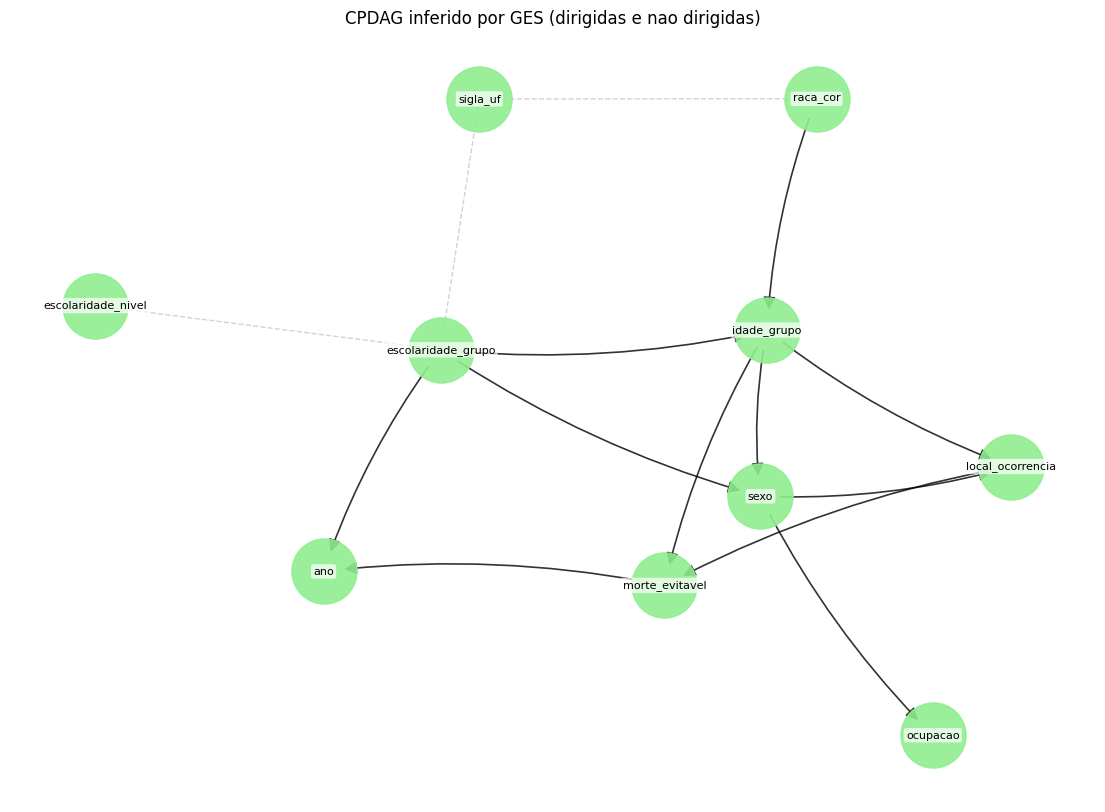

In [22]:
# Re-plot rapido (sem recomputar o GES)
required = ['node_names', 'directed_edges', 'undirected_edges']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Variaveis ausentes: {missing}. Rode a celula anterior primeiro.")

show_undirected = True
layout = 'kamada_kawai'  # 'kamada_kawai', 'spring' ou 'circular'

base_graph = nx.Graph()
base_graph.add_nodes_from(node_names)
base_graph.add_edges_from(directed_edges)
if show_undirected:
    base_graph.add_edges_from(undirected_edges)

if layout == 'kamada_kawai':
    pos = nx.kamada_kawai_layout(base_graph)
elif layout == 'circular':
    pos = nx.circular_layout(base_graph)
else:
    k = 1.5 / np.sqrt(len(node_names))
    pos = nx.spring_layout(base_graph, seed=42, k=k, iterations=200)

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G_dir, pos, node_size=2200, node_color='lightgreen', alpha=0.9)
nx.draw_networkx_labels(
    G_dir,
    pos,
    font_size=8,
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7)
 )
nx.draw_networkx_edges(
    G_dir,
    pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=18,
    width=1.2,
    alpha=0.8,
    min_source_margin=15,
    min_target_margin=15,
    connectionstyle='arc3,rad=0.08'
 )
if show_undirected:
    nx.draw_networkx_edges(G_und, pos, style='dashed', edge_color='gray', width=1.0, alpha=0.35)

plt.title('CPDAG inferido por GES (dirigidas e nao dirigidas)')
plt.axis('off')
plt.show()

## Comparacao e bootstrap

A proxima celula compara `maxP` e roda bootstrap.
Ajuste `maxp_values`, `bootstrap_iters` e `bootstrap_sample_size` conforme tempo.

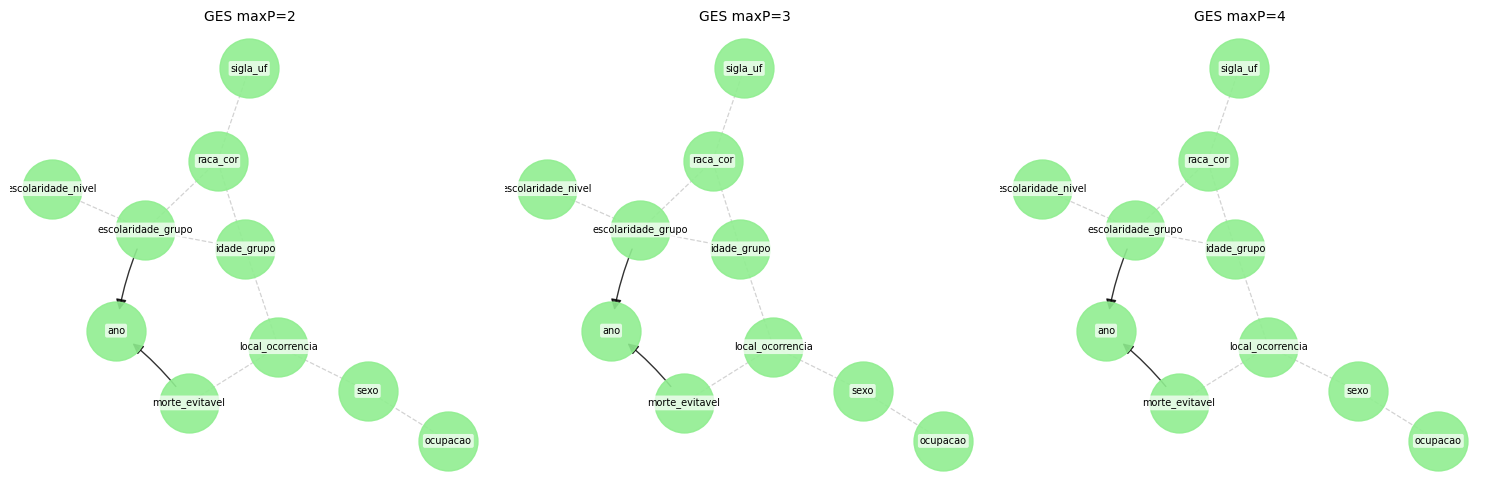

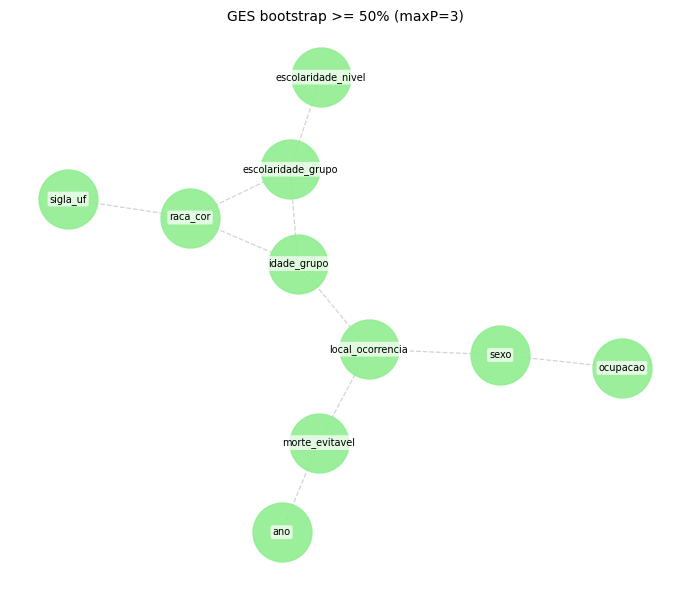

,edge,freq,type
4,escolaridade_grupo -- idade_grupo,1.0,undirected
10,escolaridade_grupo -- escolaridade_nivel,1.0,undirected
7,local_ocorrencia -- sexo,1.0,undirected
6,ocupacao -- sexo,1.0,undirected
5,idade_grupo -- local_ocorrencia,1.0,undirected
12,local_ocorrencia -- morte_evitavel,1.0,undirected
11,ano -- morte_evitavel,1.0,undirected
8,escolaridade_grupo -- raca_cor,0.9,undirected
3,idade_grupo -- raca_cor,0.9,undirected
9,raca_cor -- sigla_uf,0.9,undirected


In [23]:
# Comparacao por maxP e bootstrap do GES
from collections import Counter

required = ['df_model', 'encode_discrete', 'extract_edges_from_adjacency']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Variaveis ausentes: {missing}. Rode as celulas anteriores primeiro.")

def run_ges_once(data, maxP, sample_size, seed):
    if len(data) > sample_size:
        df_sample = data.sample(n=sample_size, random_state=seed)
    else:
        df_sample = data
    df_enc, _ = encode_discrete(df_sample)
    X = df_enc.to_numpy()
    names = list(df_enc.columns)
    record = ges(X=X, score_func='local_score_BDeu', maxP=maxP, node_names=names)
    G = record['G']
    directed, undirected = extract_edges_from_adjacency(G)
    return names, directed, undirected

def plot_cpdag_from_edges(ax, node_names, directed_edges, undirected_edges, title, layout='kamada_kawai', show_undirected=True):
    G_dir = nx.DiGraph()
    G_und = nx.Graph()
    G_dir.add_nodes_from(node_names)
    G_und.add_nodes_from(node_names)
    G_dir.add_edges_from(directed_edges)
    G_und.add_edges_from(undirected_edges)

    base_graph = nx.Graph()
    base_graph.add_nodes_from(node_names)
    base_graph.add_edges_from(directed_edges)
    if show_undirected:
        base_graph.add_edges_from(undirected_edges)

    if layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(base_graph)
    elif layout == 'circular':
        pos = nx.circular_layout(base_graph)
    else:
        k = 1.5 / np.sqrt(len(node_names))
        pos = nx.spring_layout(base_graph, seed=42, k=k, iterations=200)

    nx.draw_networkx_nodes(G_dir, pos, node_size=1800, node_color='lightgreen', alpha=0.9, ax=ax)
    nx.draw_networkx_labels(
        G_dir,
        pos,
        font_size=7,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7),
        ax=ax
    )
    nx.draw_networkx_edges(
        G_dir,
        pos,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=16,
        width=1.0,
        alpha=0.8,
        min_source_margin=15,
        min_target_margin=15,
        connectionstyle='arc3,rad=0.08',
        ax=ax
    )
    if show_undirected:
        nx.draw_networkx_edges(G_und, pos, style='dashed', edge_color='gray', width=0.9, alpha=0.35, ax=ax)

    ax.set_title(title, fontsize=10)
    ax.axis('off')

# 1) Comparacao por maxP (um grafo por valor)
maxp_values = [2, 3, 4]
sample_size = 20000
layout = 'kamada_kawai'
show_undirected = True

fig, axes = plt.subplots(1, len(maxp_values), figsize=(5 * len(maxp_values), 5))
if len(maxp_values) == 1:
    axes = [axes]
for ax, maxP in zip(axes, maxp_values):
    node_names, directed, undirected = run_ges_once(df_model, maxP=maxP, sample_size=sample_size, seed=42)
    plot_cpdag_from_edges(
        ax,
        node_names,
        directed,
        undirected,
        title=f"GES maxP={maxP}",
        layout=layout,
        show_undirected=show_undirected
    )
plt.tight_layout()
plt.show()

# 2) Bootstrap do GES (frequencia de arestas)
bootstrap_iters = 10
bootstrap_sample_size = 15000
bootstrap_maxP = 3
freq_threshold = 0.5
rng = np.random.default_rng(42)

directed_counts = Counter()
undirected_counts = Counter()

for _ in range(bootstrap_iters):
    seed = int(rng.integers(1, 1_000_000))
    _, directed, undirected = run_ges_once(
        df_model,
        maxP=bootstrap_maxP,
        sample_size=bootstrap_sample_size,
        seed=seed
    )
    directed_counts.update(directed)
    undirected_counts.update(tuple(sorted(edge)) for edge in undirected)

stable_directed = [edge for edge, c in directed_counts.items() if c / bootstrap_iters >= freq_threshold]
stable_undirected = [edge for edge, c in undirected_counts.items() if c / bootstrap_iters >= freq_threshold]

if not stable_directed and not stable_undirected:
    print("Nenhuma aresta acima do limiar de frequencia. Reduza freq_threshold ou aumente iteracoes.")
else:
    node_names = list(df_model.columns)
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    plot_cpdag_from_edges(
        ax,
        node_names,
        stable_directed,
        stable_undirected,
        title=f"GES bootstrap >= {int(freq_threshold * 100)}% (maxP={bootstrap_maxP})",
        layout=layout,
        show_undirected=True
    )
    plt.tight_layout()
    plt.show()

# Tabela com frequencias
rows = []
for edge, c in directed_counts.items():
    rows.append({"edge": f"{edge[0]} -> {edge[1]}", "freq": c / bootstrap_iters, "type": "directed"})
for edge, c in undirected_counts.items():
    rows.append({"edge": f"{edge[0]} -- {edge[1]}", "freq": c / bootstrap_iters, "type": "undirected"})
freq_table = pd.DataFrame(rows).sort_values(by="freq", ascending=False)
freq_table.head(20)

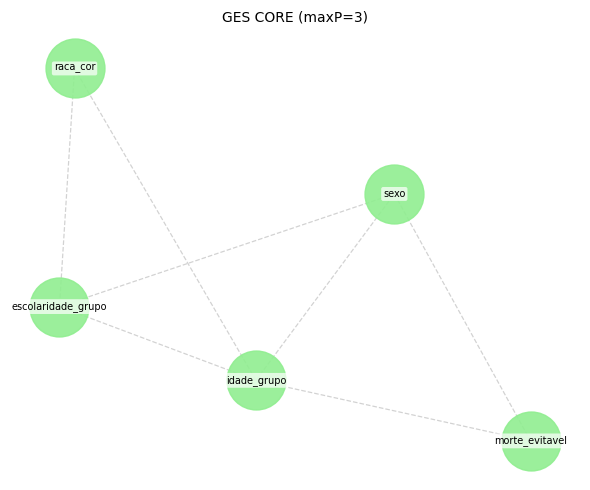

In [24]:
# 0) Bloco CORE (somente variaveis centrais do DAG)
core_cols = [
    'idade_grupo',
    'sexo',
    'raca_cor',
    'escolaridade_grupo',
    'sigla_uf',
    'ano',
    'morte_evitavel'
 ]
df_core = df_model[core_cols].dropna().copy()

core_maxP = 3
core_sample_size = 30000
node_names, directed, undirected = run_ges_once(
    df_core,
    maxP=core_maxP,
    sample_size=core_sample_size,
    seed=42
 )

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
plot_cpdag_from_edges(
    ax,
    node_names,
    directed,
    undirected,
    title=f"GES CORE (maxP={core_maxP})",
    layout=layout,
    show_undirected=True
 )
plt.tight_layout()
plt.show()